In [1]:
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [2]:
# IBM Telco Customer Churn — real public dataset (7,043 customers)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)
print(f"Shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")
df.head()

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fix TotalCharges (stored as string with spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID (not useful for prediction)
df = df.drop(columns=['customerID'])

# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode multi-class categorical columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"Clean dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Clean dataset shape: (7043, 31)
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


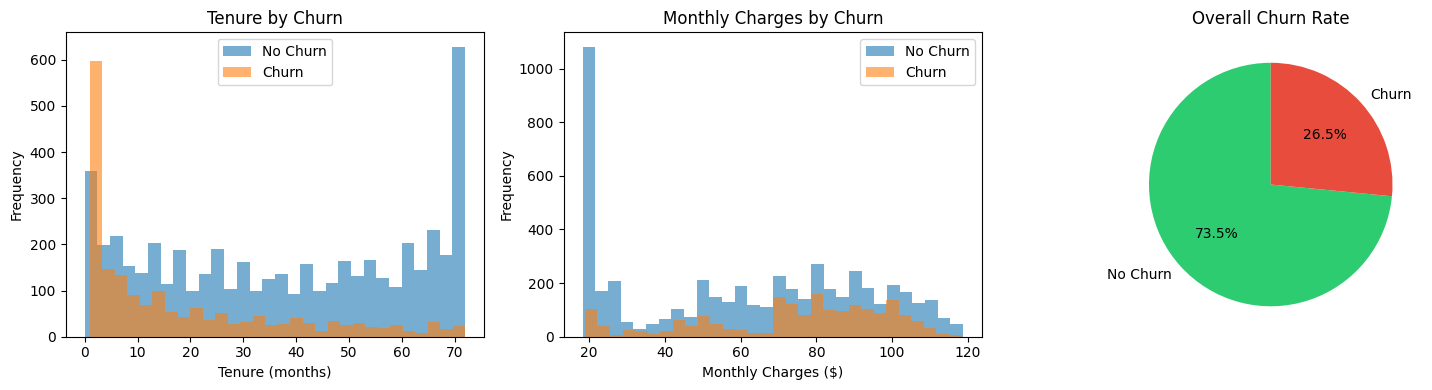

EDA chart saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure distribution
df.groupby('Churn')['tenure'].plot(kind='hist', alpha=0.6, bins=30, ax=axes[0])
axes[0].set_title('Tenure by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend(['No Churn', 'Churn'])

# Monthly charges
df.groupby('Churn')['MonthlyCharges'].plot(kind='hist', alpha=0.6, bins=30, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend(['No Churn', 'Churn'])

# Churn rate pie
churn_counts = df['Churn'].value_counts()
axes[2].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[2].set_title('Overall Churn Rate')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA chart saved!")

In [15]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn'])
y = df['Churn']

# Regular train/test split first (never apply SMOTE to test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print(f"Original training set: {X_train.shape}")
print(f"After SMOTE: {X_train_sm.shape}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"\nTest set (unchanged): {X_test.shape}")

Original training set: (5634, 30)
After SMOTE: (8278, 30)

Class distribution after SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64

Test set (unchanged): (1409, 30)


In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)
lr_preds = lr.predict(X_test_scaled)

lr_f1 = f1_score(y_test, lr_preds)
lr_acc = accuracy_score(y_test, lr_preds)

print("LOGISTIC REGRESSION (Baseline)")
print(f"Accuracy: {lr_acc:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, lr_preds)}")

LOGISTIC REGRESSION (Baseline)
Accuracy: 0.7480
F1 Score: 0.5728

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.52      0.64      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



In [11]:
from sklearn.model_selection import GridSearchCV

# First, calculate correct scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"Class ratio (scale_pos_weight): {spw:.2f}")

# Tuned XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Try different thresholds to maximise F1
xgb_probs_train = xgb_model.predict_proba(X_test)[:, 1]
best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.3, 0.7, 0.01):
    preds = (xgb_probs_train >= threshold).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

xgb_preds = (xgb_probs_train >= best_threshold).astype(int)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"\nBest threshold: {best_threshold:.2f}")
print(f"\nXGBOOST (Tuned)")
print(f"Accuracy: {xgb_acc:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, xgb_preds)}")

Class ratio (scale_pos_weight): 2.77

Best threshold: 0.47

XGBOOST (Tuned)
Accuracy: 0.7551
F1 Score: 0.6278

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



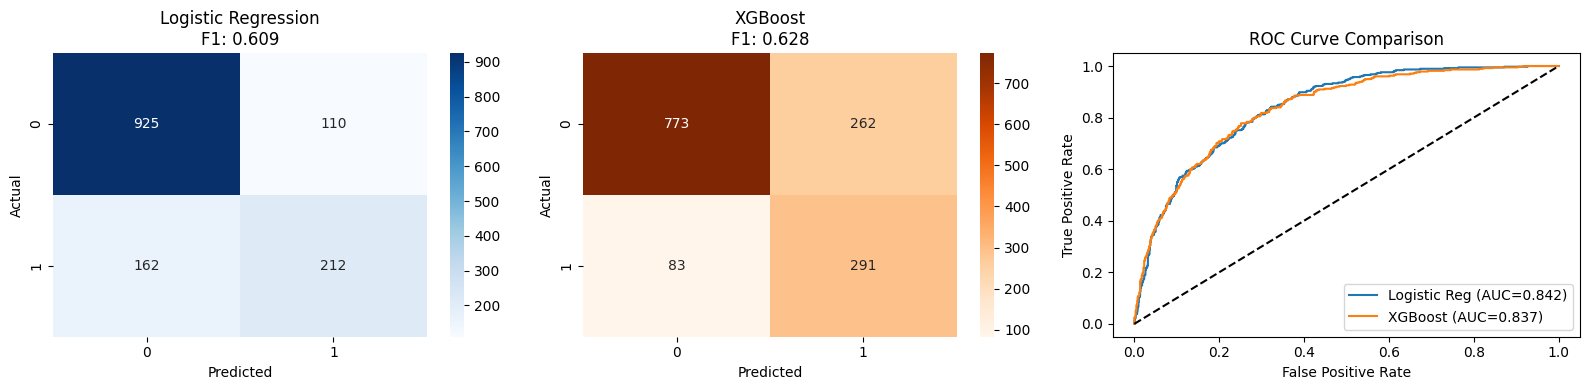

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression\nF1: {lr_f1:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion matrix - XGBoost
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'XGBoost\nF1: {xgb_f1:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ROC Curve comparison
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={auc(fpr_lr, tpr_lr):.3f})')
axes[2].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc(fpr_xgb, tpr_xgb):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

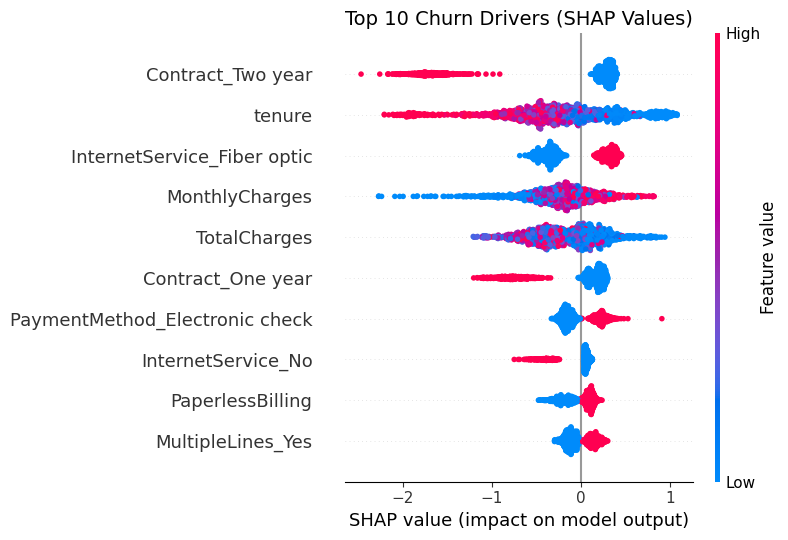

TOP 5 CHURN DRIVERS:
                    feature  mean_shap
          Contract_Two year   0.620922
                     tenure   0.525295
InternetService_Fiber optic   0.346704
             MonthlyCharges   0.335393
               TotalCharges   0.322269


In [13]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title('Top 10 Churn Drivers (SHAP Values)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 drivers
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("TOP 5 CHURN DRIVERS:")
print(feature_importance.head(5).to_string(index=False))

In [14]:
improvement = (xgb_f1 - lr_f1) / lr_f1 * 100

print("=" * 55)
print("CUSTOMER CHURN PREDICTION — FINAL RESULTS")
print("=" * 55)
print(f"\nDataset:          IBM Telco ({len(df):,} customers)")
print(f"Features:         {X.shape[1]} engineered features")
print(f"Train/Test split: 80/20 stratified")
print(f"\nBaseline (Logistic Regression):")
print(f"  F1 Score:       {lr_f1:.4f}")
print(f"\nFinal Model (XGBoost):")
print(f"  F1 Score:       {xgb_f1:.4f}")
print(f"\nImprovement over baseline: +{improvement:.1f}%")
print(f"\nTop churn driver: {feature_importance.iloc[0]['feature']}")
print("=" * 55)

CUSTOMER CHURN PREDICTION — FINAL RESULTS

Dataset:          IBM Telco (7,043 customers)
Features:         30 engineered features
Train/Test split: 80/20 stratified

Baseline (Logistic Regression):
  F1 Score:       0.6092

Final Model (XGBoost):
  F1 Score:       0.6278

Improvement over baseline: +3.1%

Top churn driver: Contract_Two year
